### Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

### Generate Dataset 

In [4]:
# True relation: y = 0.5x^2 + 1.5x + 2 + noise
X = 6 * np.random.rand(100, 1) - 3
noise = np.random.randn(100, 1)
y = 0.5 * X**2 + 1.5 * X + 2 + noise

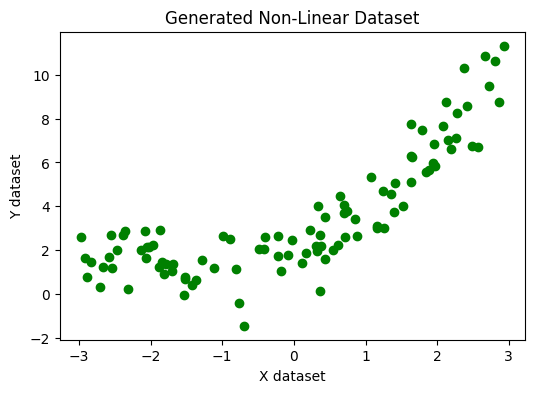

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='green')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')
plt.title('Generated Non‑Linear Dataset')
plt.show()

### Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Simple Linear Regression (Baseline Model)

In [8]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Evaluation

In [9]:
lin_pred = lin_reg.predict(X_test)
lin_score = r2_score(y_test, lin_pred)
print("Linear Regression R2 Score:", lin_score)

Linear Regression R2 Score: 0.6988777494848607


### Visualization

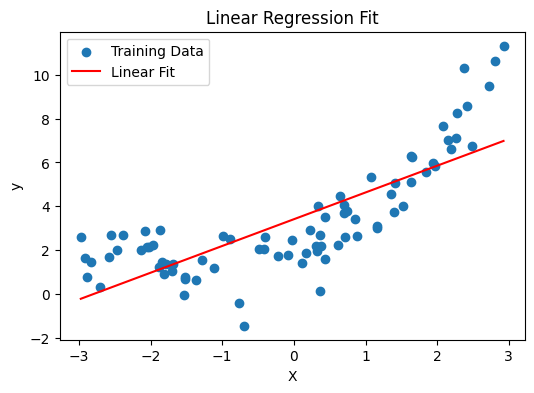

In [10]:
sort_idx = np.argsort(X_train[:, 0])
X_train_sorted = X_train[sort_idx]
lin_train_pred = lin_reg.predict(X_train_sorted)

plt.figure(figsize=(6, 4))
plt.scatter(X_train, y_train, label='Training Data')
plt.plot(X_train_sorted, lin_train_pred, color='red', label='Linear Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression Fit')
plt.show()

### Polynomial Regression (Degree 2)

In [11]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train)   # fit ONLY on training
X_test_poly2 = poly2.transform(X_test)          # transform test

poly2_model = LinearRegression()
poly2_model.fit(X_train_poly2, y_train)

poly2_pred = poly2_model.predict(X_test_poly2)
poly2_score = r2_score(y_test, poly2_pred)
print("Polynomial Degree 2 R2 Score:", poly2_score)

Polynomial Degree 2 R2 Score: 0.8646432967995795


### Plot using smooth curve

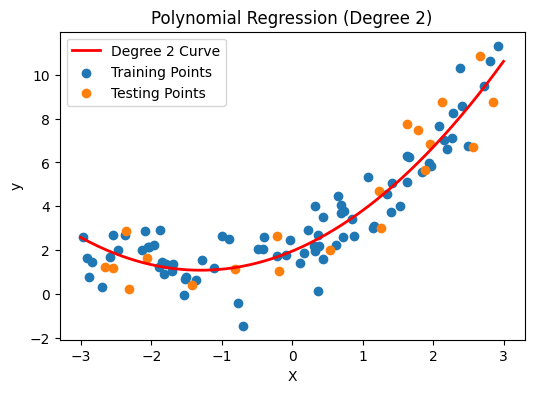

In [12]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly2 = poly2.transform(X_new)
y_new2 = poly2_model.predict(X_new_poly2)

plt.figure(figsize=(6, 4))
plt.plot(X_new, y_new2, color='red', linewidth=2, label='Degree 2 Curve')
plt.scatter(X_train, y_train, label='Training Points')
plt.scatter(X_test, y_test, label='Testing Points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Regression (Degree 2)')
plt.show()


### Polynomial Regression (Degree 3)

In [13]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

poly3_model = LinearRegression()
poly3_model.fit(X_train_poly3, y_train)

poly3_pred = poly3_model.predict(X_test_poly3)
poly3_score = r2_score(y_test, poly3_pred)
print("Polynomial Degree 3 R2 Score:", poly3_score)

Polynomial Degree 3 R2 Score: 0.8507327004039342


### Curve Plot

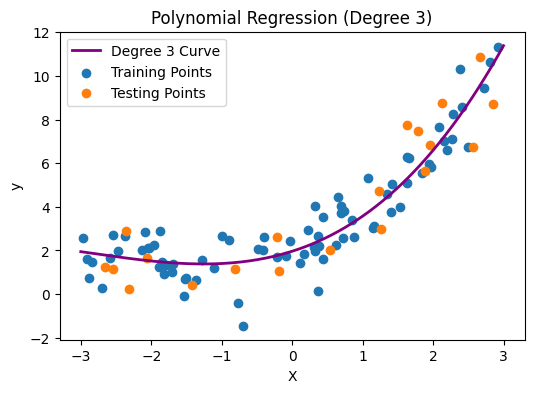

In [14]:
X_new_poly3 = poly3.transform(X_new)
y_new3 = poly3_model.predict(X_new_poly3)

plt.figure(figsize=(6, 4))
plt.plot(X_new, y_new3, color='purple', linewidth=2, label='Degree 3 Curve')
plt.scatter(X_train, y_train, label='Training Points')
plt.scatter(X_test, y_test, label='Testing Points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Regression (Degree 3)')
plt.show()

### Using Pipeline

In [16]:
def polynomial_pipeline(degree):
    model = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_new)

    plt.figure(figsize=(6, 4))
    plt.plot(X_new, y_pred, linewidth=2, label=f'Degree {degree}')
    plt.scatter(X_train, y_train, label='Training Points')
    plt.scatter(X_test, y_test, label='Testing Points')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.title(f'Polynomial Pipeline (Degree {degree})')
    plt.show()

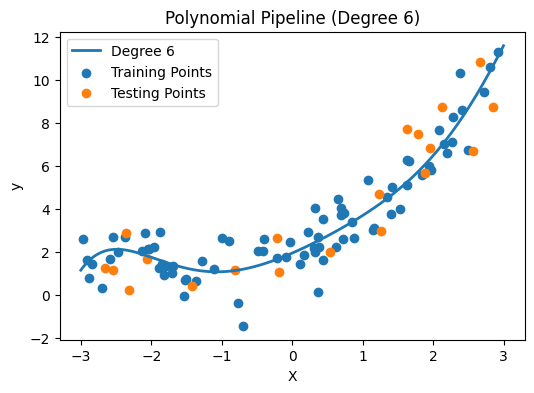

In [17]:
polynomial_pipeline(6)